In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Connect to PostgreSQL
engine = create_engine('postgresql://postgres@localhost:5432/india_air_quality')

# Load city_day data
df = pd.read_sql('SELECT * FROM city_day', engine)

print(df.shape)
print(df.dtypes)
df.head()

(29531, 16)
city              str
date           object
pm25          float64
pm10          float64
no            float64
no2           float64
nox           float64
nh3           float64
co            float64
so2           float64
o3            float64
benzene       float64
toluene       float64
xylene        float64
aqi           float64
aqi_bucket        str
dtype: object


,city,date,pm25,pm10,no,no2,nox,nh3,co,so2,o3,benzene,toluene,xylene,aqi,aqi_bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


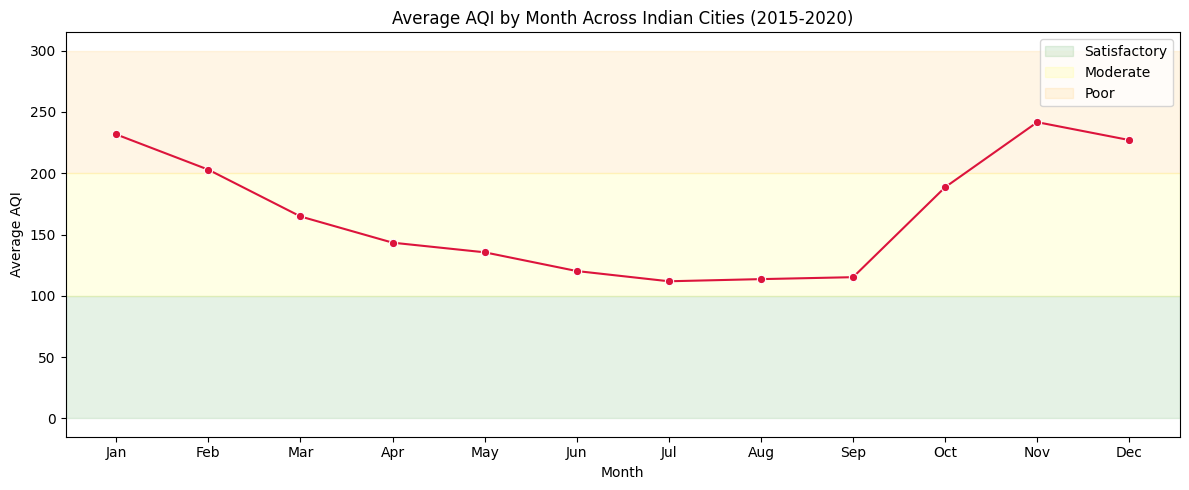

In [4]:
# Seasonal AQI trend
df['Date'] = pd.to_datetime(df['date'])
df['Month'] = df['Date'].dt.month

monthly = df.groupby('Month')['aqi'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='Month', y='aqi', marker='o', color='crimson')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average AQI by Month Across Indian Cities (2015-2020)')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.axhspan(0, 100, alpha=0.1, color='green', label='Satisfactory')
plt.axhspan(100, 200, alpha=0.1, color='yellow', label='Moderate')
plt.axhspan(200, 300, alpha=0.1, color='orange', label='Poor')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/seasonal_aqi_trend.png', dpi=150)
plt.show()

/var/folders/zn/j6rbl2pn65g2dy0hm3qf27v80000gn/T/ipykernel_9777/3473770268.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=city_avg, x='aqi', y='city', palette='RdYlGn_r')


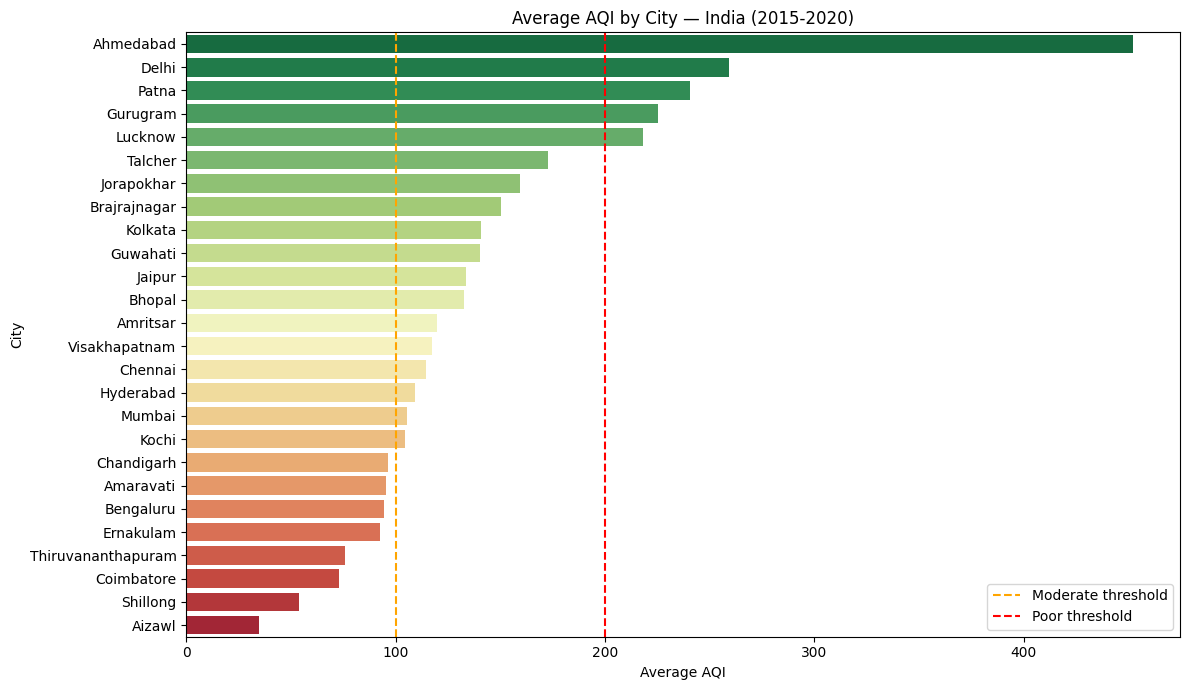

In [5]:
# City AQI rankings
city_avg = df.groupby('city')['aqi'].mean().dropna().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
bars = sns.barplot(data=city_avg, x='aqi', y='city', palette='RdYlGn_r')
plt.axvline(x=100, color='orange', linestyle='--', label='Moderate threshold')
plt.axvline(x=200, color='red', linestyle='--', label='Poor threshold')
plt.title('Average AQI by City — India (2015-2020)')
plt.xlabel('Average AQI')
plt.ylabel('City')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/city_aqi_ranking.png', dpi=150)
plt.show()


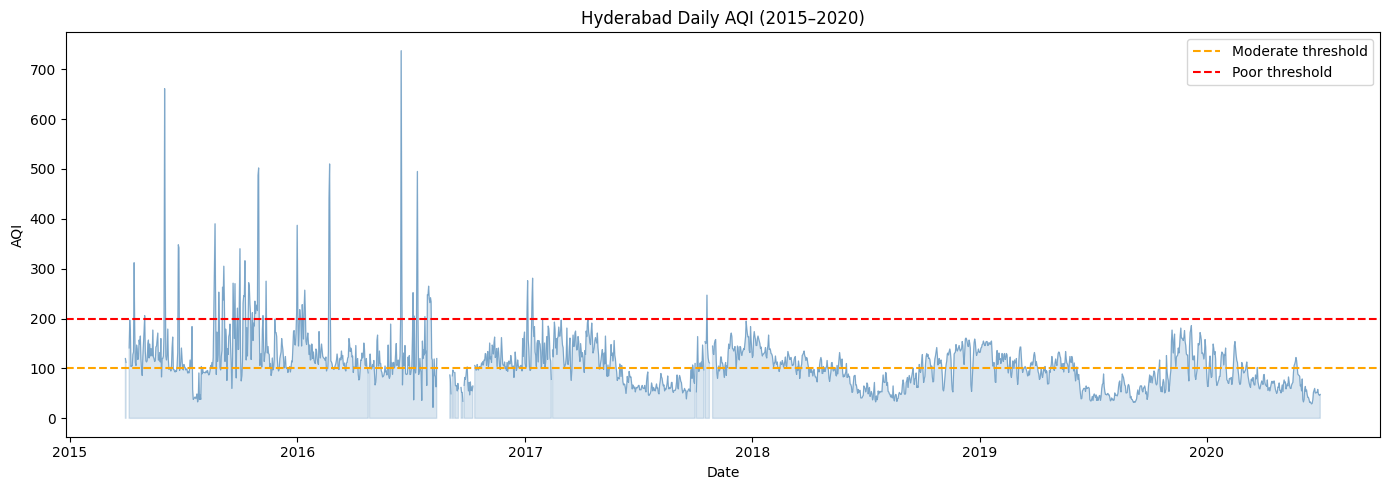

Hyderabad avg AQI: 109.2
Days above 200 (Poor): 71
Days above 100 (Moderate): 1029


In [6]:
# Hyderabad AQI trend over time
hyd = df[df['city'] == 'Hyderabad'].copy()
hyd['Date'] = pd.to_datetime(hyd['date'])
hyd = hyd.sort_values('Date')

plt.figure(figsize=(14, 5))
plt.plot(hyd['Date'], hyd['aqi'], color='steelblue', alpha=0.6, linewidth=0.8)
plt.fill_between(hyd['Date'], hyd['aqi'], alpha=0.2, color='steelblue')
plt.axhline(y=100, color='orange', linestyle='--', label='Moderate threshold')
plt.axhline(y=200, color='red', linestyle='--', label='Poor threshold')
plt.title('Hyderabad Daily AQI (2015–2020)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/hyderabad_aqi_trend.png', dpi=150)
plt.show()

print(f"Hyderabad avg AQI: {hyd['aqi'].mean():.1f}")
print(f"Days above 200 (Poor): {(hyd['aqi'] > 200).sum()}")
print(f"Days above 100 (Moderate): {(hyd['aqi'] > 100).sum()}")

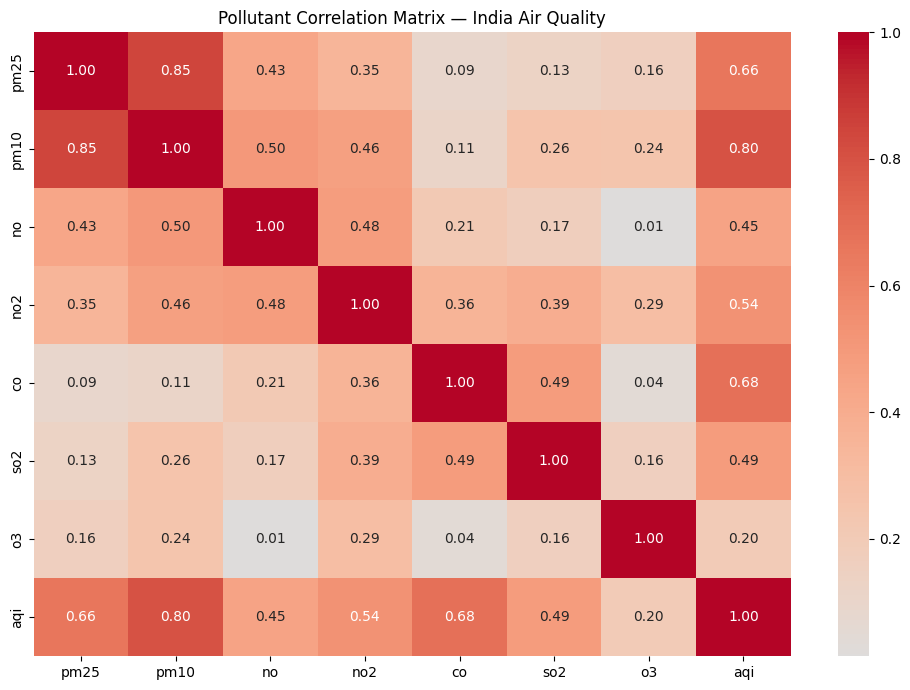

In [7]:
# Pollutant correlation heatmap
pollutants = ['pm25', 'pm10', 'no', 'no2', 'co', 'so2', 'o3', 'aqi']
corr = df[pollutants].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pollutant Correlation Matrix — India Air Quality')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()